In [1]:
from google.colab import drive
import pandas as pd

drive.mount('/drive')

df = pd.read_csv('/drive/MyDrive/Customer Churn Prediction/customer_churn_dataset-testing-master.csv')

Mounted at /drive


In [2]:
type(df)

pandas.core.frame.DataFrame

In [3]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [5]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [6]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
0,0.526315
1,0.473685


In [7]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [8]:
df.groupby("Churn")["Last Interaction"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,33881.0,15.521944,8.620364,1.0,8.0,16.0,23.0,30.0
1,30493.0,15.473191,8.658541,1.0,8.0,15.0,23.0,30.0


In [11]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_array = encoder.fit_transform(df[["Gender", "Subscription Type", "Contract Length"]])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(["Gender", "Subscription Type", "Contract Length"]))
df = pd.concat([df, encoded_df], axis=1)
df.drop(["Gender", "Subscription Type", "Contract Length"], axis=1, inplace=True)

df.corr()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
CustomerID,1.000000,0.043287,0.103296,-0.062699,0.164175,0.290684,-0.037068,-0.003718,0.529832,-0.085960,-0.004401,0.000667,0.032902,-0.026510
Age,0.043287,1.000000,-0.007763,-0.038331,0.005014,-0.016132,0.006490,-0.000148,0.063457,0.001800,-0.004582,0.006161,0.001311,-0.000585
Tenure,0.103296,-0.007763,1.000000,0.023485,0.060065,0.055963,0.009474,0.005770,0.195327,0.029418,-0.002881,0.005078,-0.003306,0.002310
Usage Frequency,-0.062699,-0.038331,0.023485,1.000000,-0.014072,0.031132,0.001527,-0.009192,-0.115098,-0.006907,0.000364,-0.000744,0.008066,0.005677
Support Calls,0.164175,0.005014,0.060065,-0.014072,1.000000,0.064298,0.021750,0.001666,0.304631,0.035418,-0.005009,-0.000250,-0.016492,0.005705
Payment Delay,0.290684,-0.016132,0.055963,0.031132,0.064298,1.000000,-0.031119,-0.008076,0.557386,-0.058578,-0.003979,0.000680,0.028522,-0.012800
Total Spend,-0.037068,0.006490,0.009474,0.001527,0.021750,-0.031119,1.000000,-0.007692,-0.078867,0.029337,0.006925,-0.006608,0.024744,-0.006814
Last Interaction,-0.003718,-0.000148,0.005770,-0.009192,0.001666,-0.008076,-0.007692,1.000000,-0.002818,-0.000472,-0.005186,0.000662,0.000819,0.002925
Churn,0.529832,0.063457,0.195327,-0.115098,0.304631,0.557386,-0.078867,-0.002818,1.000000,-0.164549,-0.012334,-0.000539,0.061464,-0.046000
Gender_Male,-0.085960,0.001800,0.029418,-0.006907,0.035418,-0.058578,0.029337,-0.000472,-0.164549,1.000000,0.000281,0.005380,-0.028741,0.006856


In [12]:
corr = df.corr(numeric_only=True)
corr["Churn"].abs().sort_values(ascending=False)

,Churn
Churn,1.000000
Payment Delay,0.557386
CustomerID,0.529832
Support Calls,0.304631
Tenure,0.195327
Gender_Male,0.164549
Usage Frequency,0.115098
Total Spend,0.078867
Age,0.063457
Contract Length_Monthly,0.061464


In [13]:
import numpy as np

corr = df.corr(numeric_only=True)

mask = corr.where(~np.tril(np.ones(corr.shape)).astype(bool))

strong_corr = (
    mask.stack()
        .sort_values(key=abs, ascending=False)
)

strong_corr.head(20)

,,0
Payment Delay,Churn,0.557386
CustomerID,Churn,0.529832
Contract Length_Monthly,Contract Length_Quarterly,-0.500669
Subscription Type_Premium,Subscription Type_Standard,-0.500122
Support Calls,Churn,0.304631
CustomerID,Payment Delay,0.290684
Tenure,Churn,0.195327
Churn,Gender_Male,-0.164549
CustomerID,Support Calls,0.164175
Usage Frequency,Churn,-0.115098


In [15]:
df["Churn"].value_counts(normalize=True)

corr = (
    df.corr(numeric_only=True)["Churn"]
      .drop("Churn")
      .abs()
      .sort_values(ascending=False)
)

corr.head(10)

,Churn
Payment Delay,0.557386
CustomerID,0.529832
Support Calls,0.304631
Tenure,0.195327
Gender_Male,0.164549
Usage Frequency,0.115098
Total Spend,0.078867
Age,0.063457
Contract Length_Monthly,0.061464
Contract Length_Quarterly,0.046000


<Axes: xlabel='CustomerID', ylabel='Density'>

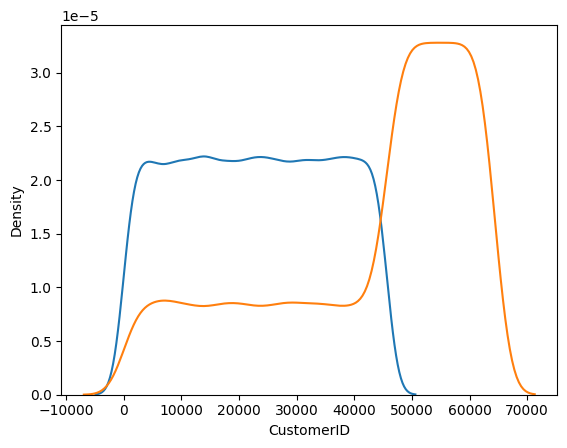

In [16]:
import seaborn as sns

sns.kdeplot(df[df["Churn"]==0]["CustomerID"])
sns.kdeplot(df[df["Churn"]==1]["CustomerID"])

<Axes: xlabel='Payment Delay', ylabel='Density'>

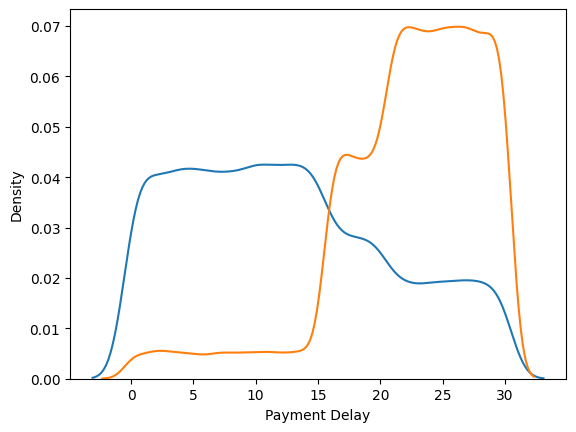

In [17]:
import seaborn as sns

sns.kdeplot(df[df["Churn"]==0]["Payment Delay"])
sns.kdeplot(df[df["Churn"]==1]["Payment Delay"])

<Axes: xlabel='Tenure', ylabel='Density'>

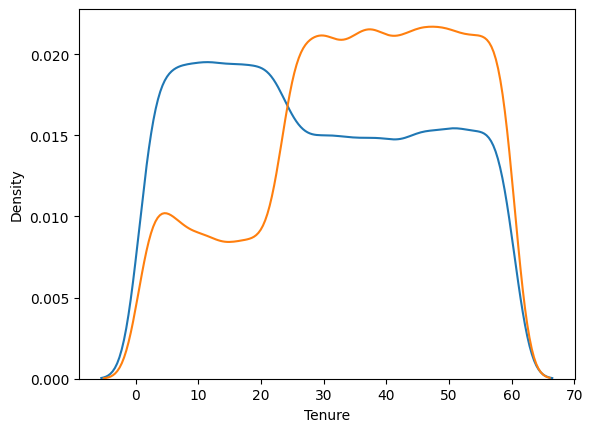

In [18]:
import seaborn as sns

sns.kdeplot(df[df["Churn"]==0]["Tenure"])
sns.kdeplot(df[df["Churn"]==1]["Tenure"])


In [19]:
df.drop(['CustomerID'], axis=1, inplace=True)

df["Churn"].value_counts(normalize=True)

corr = (
    df.corr(numeric_only=True)["Churn"]
      .drop("Churn")
      .abs()
      .sort_values(ascending=False)
)

corr.head(10)

,Churn
Payment Delay,0.557386
Support Calls,0.304631
Tenure,0.195327
Gender_Male,0.164549
Usage Frequency,0.115098
Total Spend,0.078867
Age,0.063457
Contract Length_Monthly,0.061464
Contract Length_Quarterly,0.046000
Subscription Type_Premium,0.012334


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = RandomForestClassifier()
model.fit(X_train, y_train)

res = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, model.predict(X_test))],
    "precision_score": [precision_score(y_test, model.predict(X_test))],
    "recall_score": [recall_score(y_test, model.predict(X_test))],
    "f1_score": [f1_score(y_test, model.predict(X_test))]
})

res.style.set_caption("Result with RandomForest Method")

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

print(
    importance.sort_values(
        "importance",
        ascending=False
    )
)

                       feature  importance
4                Payment Delay    0.433257
3                Support Calls    0.165399
1                       Tenure    0.113678
2              Usage Frequency    0.083063
7                  Gender_Male    0.070824
5                  Total Spend    0.049974
0                          Age    0.042380
10     Contract Length_Monthly    0.023106
6             Last Interaction    0.008917
11   Contract Length_Quarterly    0.005874
8    Subscription Type_Premium    0.001815
9   Subscription Type_Standard    0.001711


  0%|          | 0/50 [00:00<?, ?it/s]

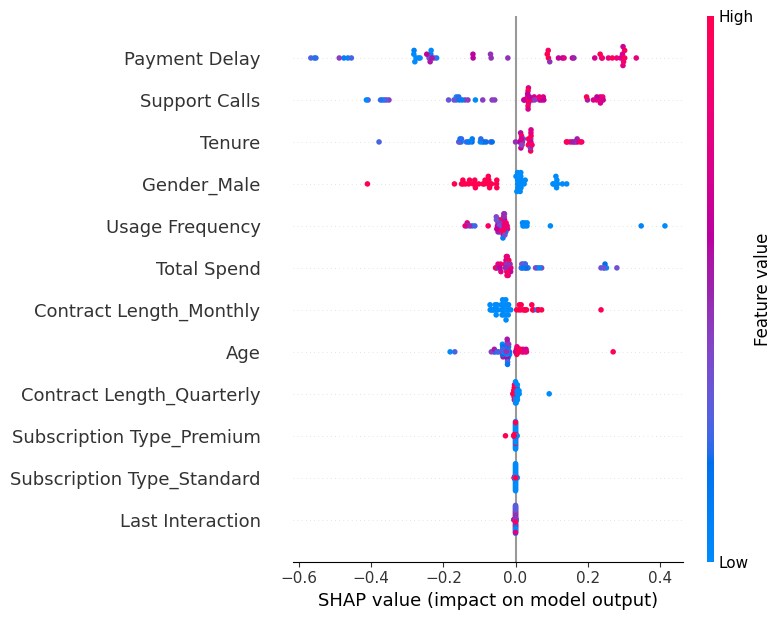

In [21]:
import shap

explainer = shap.KernelExplainer(model.predict, X_train[:100])
shap_values = explainer.shap_values(X_test[:50])
shap.summary_plot(shap_values, X_test[:50])